# 1. Configuration & Imports
Setup Kaggle dataset path and hyperparameters.


In [13]:
import os
import random
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Sampler
import torchvision.transforms as T
import torchvision.models as models

# --- CONFIGURATION ---
DATA_ROOT = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025"  # Update if Kaggle mounts it differently
MANIFEST_PATH = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025/manifest.csv"

# Episodic Settings
K_SHOTS = 10
Q_QUERIES = 1
TRAIN_EPISODES_PHASE_1 = 70   # Episodes to run with frozen backbone
TRAIN_EPISODES_PHASE_2 = 300  # Episodes to run with unfrozen backbone
EVAL_EPISODES = 10            # Episodes to run during evaluation

# Learning Rates
LR_FROZEN = 5e-5      # Higher LR when backbone is frozen
LR_UNFROZEN = 1e-6    # 10x lower LR for fine-tuning the un-frozen backbone
gamma = 0.8

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")


Using device: cuda


# 2. Dataset & Sampler


In [14]:
class TumorDataset(Dataset):
    def __init__(self, manifest_path=MANIFEST_PATH, data_root=DATA_ROOT, image_size=(256, 256)):
        self.data_root = data_root
        self.image_size = image_size
        
        # We will parse the manifest.csv and store valid samples
        self.samples = []
        self.label_to_indices = {}
        
        df = pd.read_csv(manifest_path)
        
        # Filter for segmentation task and mask entries
        df_seg = df[(df['task'] == 'segmentation') & (df['is_mask'] == True)]
        
        # Exclude 'no_tumor' as requested
        df_seg = df_seg[df_seg['tumor_label'] != 'no_tumor']
        
        for idx, row in df_seg.iterrows():
            mask_path = row['relative_path'].replace('\\', '/')
            img_path = row['linked_image'].replace('\\', '/')
            label = row['tumor_label']
            
            self.samples.append({
                'image': os.path.join(self.data_root, img_path),
                'mask': os.path.join(self.data_root, mask_path),
                'label': label
            })
            
            # Group by label
            curr_idx = len(self.samples) - 1
            if label not in self.label_to_indices:
                self.label_to_indices[label] = []
            self.label_to_indices[label].append(curr_idx)
            
        self.img_transform = T.Compose([
            T.Resize(self.image_size),
            T.ToTensor(),
        ])
        
        self.mask_transform = T.Compose([
            T.Resize(self.image_size, interpolation=T.InterpolationMode.NEAREST),
            T.ToTensor(),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample['image']).convert("RGB")
        mask = Image.open(sample['mask']).convert("L")  # Greyscale for binary mask
        
        img_t = self.img_transform(img)
        mask_t = self.mask_transform(mask)
        
        # Binarize mask just in case
        mask_t = (mask_t > 0).float()
        
        return img_t, mask_t, sample['label']


class EpisodicBatchSampler(Sampler):
    def __init__(self, label_to_indices, seen_classes, num_episodes, k_shots, q_queries):
        self.label_to_indices = label_to_indices
        self.seen_classes = seen_classes
        self.num_episodes = num_episodes
        self.k_shots = k_shots
        self.q_queries = q_queries

    def __iter__(self):
        for _ in range(self.num_episodes):
            # Sample a class
            sampled_class = random.choice(self.seen_classes)
            
            # Get indices for this class
            class_indices = self.label_to_indices[sampled_class]
            
            # Sample K+Q items without replacement
            sampled_indices = random.sample(class_indices, self.k_shots + self.q_queries)
            
            yield sampled_indices

    def __len__(self):
        return self.num_episodes


# 3. Dual-Branch PANet Architecture


In [15]:
out_channels = 2048

# spatial encoder
class SpatialEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        # last 2 layers avg pool and fc layer removed
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        
        # Freeze backbone parameters
        for param in self.backbone.parameters():
            param.requires_grad = False
        
    def forward(self, x):
        return self.backbone(x)


class FrequencyEncoder(nn.Module):
    def __init__(self, in_channels=3, out_channels=out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels * 2, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, out_channels, kernel_size=3, padding=1, stride=32) 
        
    def forward(self, x):
        fft_x = torch.fft.fft2(x)
        x_freq = torch.cat([fft_x.real, fft_x.imag], dim=1)
        
        x_freq = F.relu(self.conv1(x_freq))
        x_freq = self.conv2(x_freq) 
        return x_freq


def masked_pooling(features, mask):
    """
        features: (Batch, Channels, H, W)
        mask: (Batch, 1, H, W)
    """

    # resize mask to the size of the feature maps
    if mask.shape[-2:] != features.shape[-2:]:
        mask = F.interpolate(mask, size=features.shape[-2:], mode='nearest')
    
    masked_features = features * mask
    
    sum_features = torch.sum(masked_features, dim=(-1, -2), keepdim=True) # Shape: (B, C, 1, 1)
    mask_area = torch.sum(mask, dim=(-1, -2), keepdim=True) # Shape: (B, 1, 1, 1)
    prototype = sum_features / (mask_area + 1e-8)

    return prototype


class PrototypeFusion(nn.Module):
    def __init__(self, channels=out_channels):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim=channels, num_heads=8, batch_first=True)
        
    def forward(self, p_s, p_f):
        B, C, _, _ = p_s.shape
        p_s = p_s.view(B, 1, C)
        p_f = p_f.view(B, 1, C)
        
        # Q = spatial prototype, KV = frequency prototype
        attn_output, _ = self.attention(query=p_s, key=p_f, value=p_f)
        
        p_fused = attn_output.view(B, C, 1, 1)
        return p_fused


class BandWeighting(nn.Module):
    def __init__(self, channels=out_channels):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // 4),
            nn.ReLU(),
            nn.Linear(channels // 4, channels),
            nn.Sigmoid() 
        )
        
    def forward(self, p_f):
        B, C, _, _ = p_f.shape
        p_f_flattened = p_f.view(B, C)

        weights = self.mlp(p_f_flattened).view(B, C, 1, 1)

        return p_f * weights


def compute_similarity_map(query_features, prototype):
    """
    query_features: (B, C, H, W)
    prototype: (B, C, 1, 1)
    """
    sim_map = F.cosine_similarity(query_features, prototype, dim=1) # Shape: (B, H, W)
    
    return sim_map.unsqueeze(1) # Shape: (B, 1, H, W)


def dice_loss(logits, target):
        # Dice loss on foreground
        probs = F.softmax(logits, dim=1)[:, 1, :, :] # (B, H, W)
        target_float = target.float()
        intersection = (probs * target_float).sum(dim=(1, 2))
        union = probs.sum(dim=(1, 2)) + target_float.sum(dim=(1, 2))
        dice_loss = 1.0 - (2.0 * intersection + 1e-5) / (union + 1e-5)
        dice_loss = dice_loss.mean()

        return dice_loss


class DualBranchPANet(nn.Module):
    def __init__(self):
        super().__init__()
        # Backbone output channels
        channels = 2048 
        
        self.spatial_encoder = SpatialEncoder()
        self.freq_encoder = FrequencyEncoder(in_channels=3, out_channels=channels)
        self.prototype_fusion = PrototypeFusion(channels=channels)
        self.band_weighting = BandWeighting(channels=channels)
        
        self.fusion_weight = nn.Parameter(torch.tensor(0.5))
        self.scaler = nn.Parameter(torch.tensor(20.0))
        
    def forward(self, support_img, query_img, fore_mask, back_mask=None, target=None):
        """
        Args:
            support_img: (B, K, 3, H, W) - Support images
            query_img: (B, 3, H, W) - Query image
            fore_mask: (B, K, 1, H, W) - Foreground mask
            back_mask: (B, K, 1, H, W) - Background mask (optional)
            target: (B, H, W) - Target mask (optional)
        Returns:
            logits: (B, 2, H, W) - Logits
            loss: (1, ) - Loss
        """
        B, K, C, H, W = support_img.shape
        support_img = support_img.view(B * K, C, H, W)
        fore_mask = fore_mask.view(B * K, 1, H, W)
        
        if back_mask is None:
            back_mask = 1 - fore_mask
        else:
            back_mask = back_mask.view(B * K, 1, H, W)

        # Extract features for Support Image
        f_s = self.spatial_encoder(support_img)
        f_f = self.freq_encoder(support_img)
        
        # Extract features for Query Image
        q_s = self.spatial_encoder(query_img)
        q_f = self.freq_encoder(query_img)
        
        # spatial prototypes
        p_s_fg = masked_pooling(f_s, fore_mask)   # (B*K, C, 1, 1)
        p_s_bg = masked_pooling(f_s, back_mask)   # (B*K, C, 1, 1)

        # frequency prototypes
        p_f_fg = masked_pooling(f_f, fore_mask)   # (B*K, C, 1, 1)
        p_f_bg = masked_pooling(f_f, back_mask)   # (B*K, C, 1, 1)
        
        # aggregate K shots
        p_s_fg = p_s_fg.view(B, K, -1, 1, 1).mean(dim=1)  # (B, C, 1, 1)
        p_s_bg = p_s_bg.view(B, K, -1, 1, 1).mean(dim=1)
        p_f_fg = p_f_fg.view(B, K, -1, 1, 1).mean(dim=1)
        p_f_bg = p_f_bg.view(B, K, -1, 1, 1).mean(dim=1)
        
        # prototype fusion using MHA
        p_fused_fg = self.prototype_fusion(p_s_fg, p_f_fg)
        p_fused_bg = self.prototype_fusion(p_s_bg, p_f_bg)

        # Bandweighting of frequency prototypes
        p_f_weighted_fg = self.band_weighting(p_f_fg)
        p_f_weighted_bg = self.band_weighting(p_f_bg)

        # Simalarity scores
        spatial_sim_fg = compute_similarity_map(q_s, p_fused_fg)       # (B, 1, H', W')
        spatial_sim_bg = compute_similarity_map(q_s, p_fused_bg)       # (B, 1, H', W')

        freq_sim_fg = compute_similarity_map(q_f, p_f_weighted_fg)     # (B, 1, H', W')
        freq_sim_bg = compute_similarity_map(q_f, p_f_weighted_bg)     # (B, 1, H', W')
        
        # Similarity score fusion
        sim_fg = self.fusion_weight * spatial_sim_fg + (1.0 - self.fusion_weight) * freq_sim_fg 
        sim_bg = self.fusion_weight * spatial_sim_bg + (1.0 - self.fusion_weight) * freq_sim_bg  
        
        logits = torch.cat([sim_bg, sim_fg], dim=1) * self.scaler      # (B, 2, H', W')
        
        logits = F.interpolate(
            logits, 
            size=query_img.shape[-2:], 
            mode='bilinear', 
            align_corners=False
        )  # (B, 2, H, W)

        loss = None
        if target is not None:
            ce_loss = F.cross_entropy(logits, target.long(), reduction='mean') # (1, )
            
            # Dice loss on foreground
            d_loss = dice_loss(logits, target)
            
            # Weighted loss
            loss = (1 - gamma) * ce_loss + gamma * d_loss
    
        return logits, loss

    def unfreeze_backbone(self):
        """Unfreeze the ResNet50 backbone for Phase 2 fine-tuning."""
        for param in self.spatial_encoder.backbone.parameters():
            param.requires_grad = True
        print("ResNet50 backbone unfrozen.")


# 4. Phased Training Loop & Evaluation Utilities


In [16]:
def save_visualization(support_img, query_img, gt_mask, pred_mask, fold, episode, save_dir="visualizations"):
    os.makedirs(save_dir, exist_ok=True)
    s_img = support_img[0].permute(1, 2, 0).cpu().numpy()
    q_img = query_img[0].permute(1, 2, 0).cpu().numpy()
    gt = gt_mask[0].cpu().numpy()
    pred = pred_mask[0].cpu().numpy()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(s_img)
    axes[0].set_title("Support Image (1 of K)")
    axes[0].axis("off")
    axes[1].imshow(q_img)
    axes[1].set_title("Query Image")
    axes[1].axis("off")
    axes[2].imshow(gt, cmap='gray')
    axes[2].set_title("Ground Truth Mask")
    axes[2].axis("off")
    axes[3].imshow(pred, cmap='gray')
    axes[3].set_title("Predicted Mask")
    axes[3].axis("off")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/fold_{fold}_ep_{episode}.png")
    plt.show()  # Show inline in Jupyter
    plt.close()

def run_training_phase(model, train_loader, optimizer, phase_episodes, phase_name):
    print(f"--- Starting {phase_name} ({phase_episodes} episodes) ---")
    model.train()
    total_loss = 0.0
    for ep_idx, (imgs, masks, labels) in enumerate(train_loader):
        if ep_idx >= phase_episodes:
            break
            
        imgs, masks = imgs.to(device), masks.to(device)
        support_img = imgs[:K_SHOTS].unsqueeze(0)
        support_mask = masks[:K_SHOTS].unsqueeze(0)
        query_img = imgs[K_SHOTS:].unsqueeze(0).squeeze(1)
        target_mask = masks[K_SHOTS:].squeeze(1)
        
        optimizer.zero_grad()
        logits, loss = model(support_img, query_img, support_mask, target=target_mask)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        if (ep_idx + 1) % 10 == 0:
            print(f"  {phase_name} - Episode [{ep_idx+1}/{phase_episodes}] Loss: {loss.item():.4f}")


# 5. Execute 3-Fold Cross-Validation


Available classes: ['glioma', 'meningioma', 'pituitary']

FOLD 1 | Training on: ['meningioma', 'pituitary'] | Evaluating on: ['glioma']
Using 2 GPUs!
--- Starting Phase 1 (Frozen Backbone) (70 episodes) ---


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


  Phase 1 (Frozen Backbone) - Episode [10/70] Loss: 0.8256
  Phase 1 (Frozen Backbone) - Episode [20/70] Loss: 0.7433
  Phase 1 (Frozen Backbone) - Episode [30/70] Loss: 0.8180
  Phase 1 (Frozen Backbone) - Episode [40/70] Loss: 0.8129
  Phase 1 (Frozen Backbone) - Episode [50/70] Loss: 0.8169
  Phase 1 (Frozen Backbone) - Episode [60/70] Loss: 0.7359
  Phase 1 (Frozen Backbone) - Episode [70/70] Loss: 0.7341
ResNet50 backbone unfrozen.
--- Starting Phase 2 (Unfrozen Backbone) (300 episodes) ---
  Phase 2 (Unfrozen Backbone) - Episode [10/300] Loss: 0.8090
  Phase 2 (Unfrozen Backbone) - Episode [20/300] Loss: 0.6891
  Phase 2 (Unfrozen Backbone) - Episode [30/300] Loss: 0.7520
  Phase 2 (Unfrozen Backbone) - Episode [40/300] Loss: 0.6376
  Phase 2 (Unfrozen Backbone) - Episode [50/300] Loss: 0.7988
  Phase 2 (Unfrozen Backbone) - Episode [60/300] Loss: 0.7319
  Phase 2 (Unfrozen Backbone) - Episode [70/300] Loss: 0.5150
  Phase 2 (Unfrozen Backbone) - Episode [80/300] Loss: 0.8083
  P

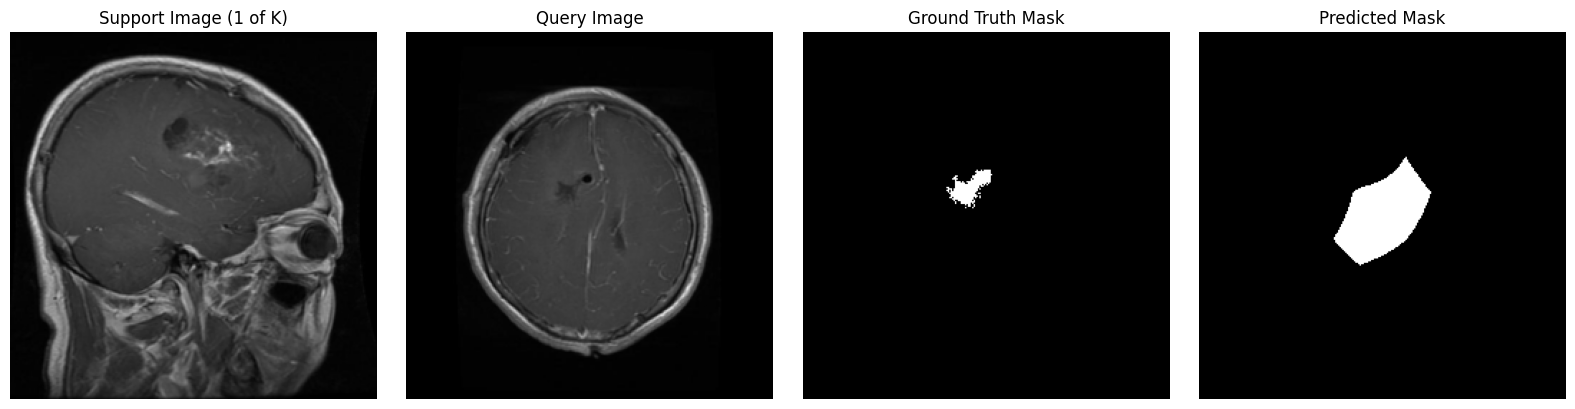

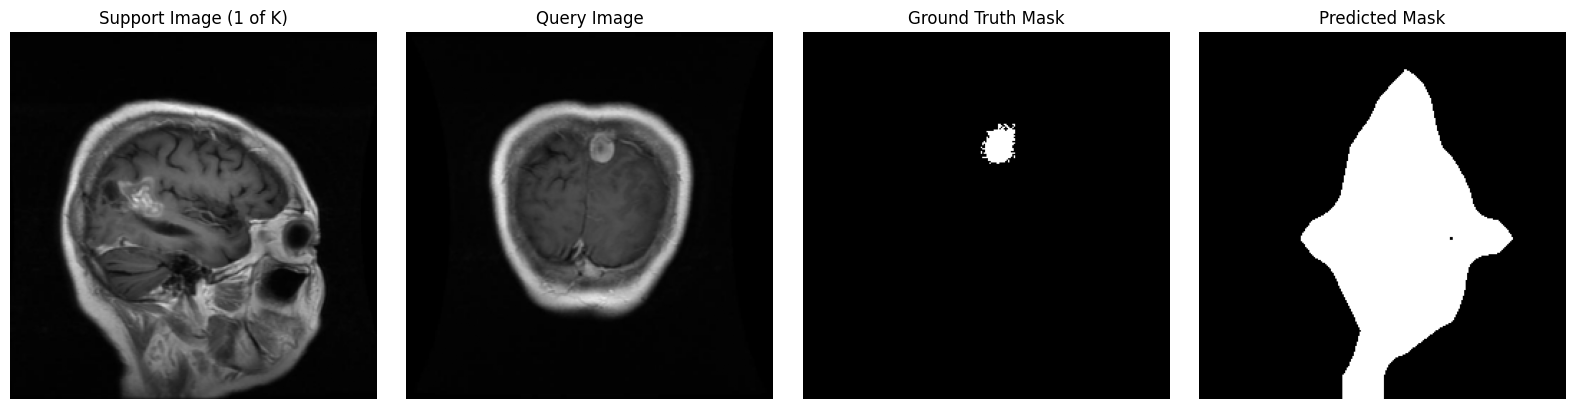

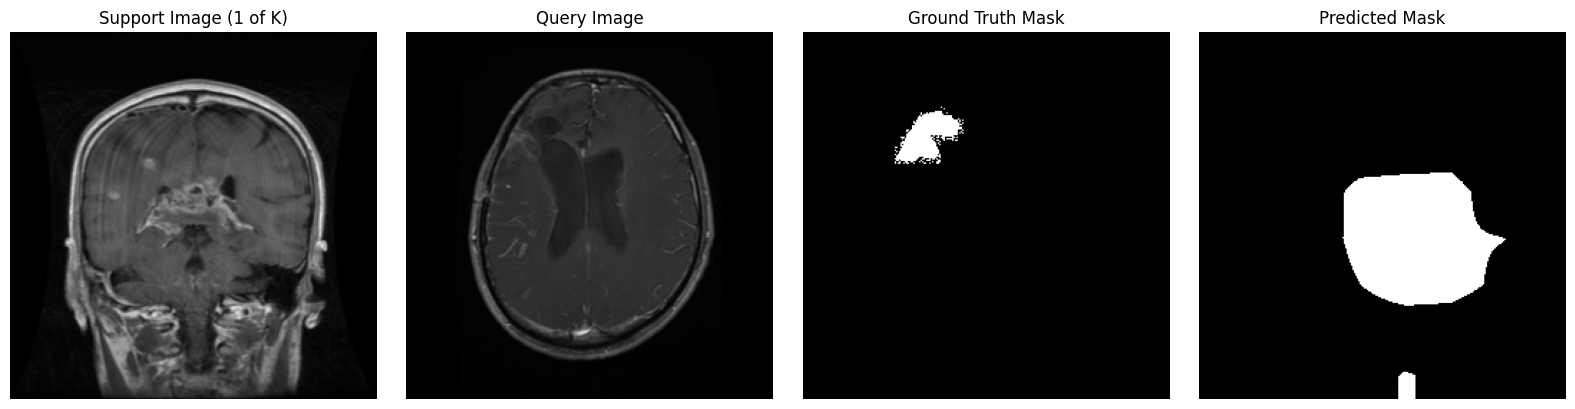

Fold 1 Results -> mIoU: 0.0631, Dice: 0.1080


FOLD 2 | Training on: ['glioma', 'pituitary'] | Evaluating on: ['meningioma']
Using 2 GPUs!
--- Starting Phase 1 (Frozen Backbone) (70 episodes) ---
  Phase 1 (Frozen Backbone) - Episode [10/70] Loss: 0.8241
  Phase 1 (Frozen Backbone) - Episode [20/70] Loss: 0.7705
  Phase 1 (Frozen Backbone) - Episode [30/70] Loss: 0.7824
  Phase 1 (Frozen Backbone) - Episode [40/70] Loss: 0.8306
  Phase 1 (Frozen Backbone) - Episode [50/70] Loss: 0.7849
  Phase 1 (Frozen Backbone) - Episode [60/70] Loss: 0.7467
  Phase 1 (Frozen Backbone) - Episode [70/70] Loss: 0.7848
ResNet50 backbone unfrozen.
--- Starting Phase 2 (Unfrozen Backbone) (300 episodes) ---
  Phase 2 (Unfrozen Backbone) - Episode [10/300] Loss: 0.7906
  Phase 2 (Unfrozen Backbone) - Episode [20/300] Loss: 0.6417
  Phase 2 (Unfrozen Backbone) - Episode [30/300] Loss: 0.7872
  Phase 2 (Unfrozen Backbone) - Episode [40/300] Loss: 0.7042
  Phase 2 (Unfrozen Backbone) - Episode [50/300] Loss: 

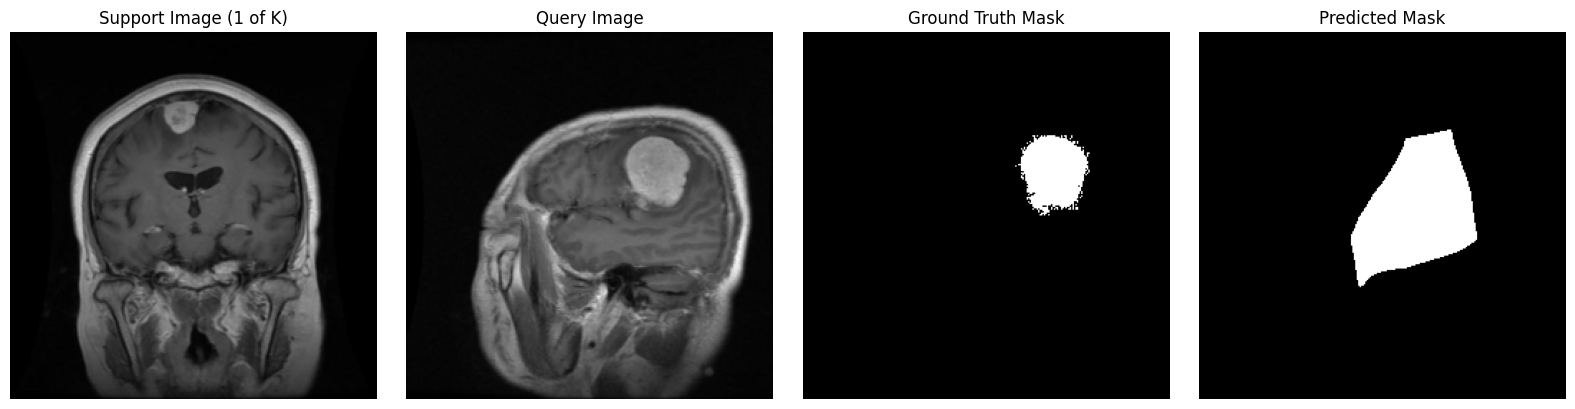

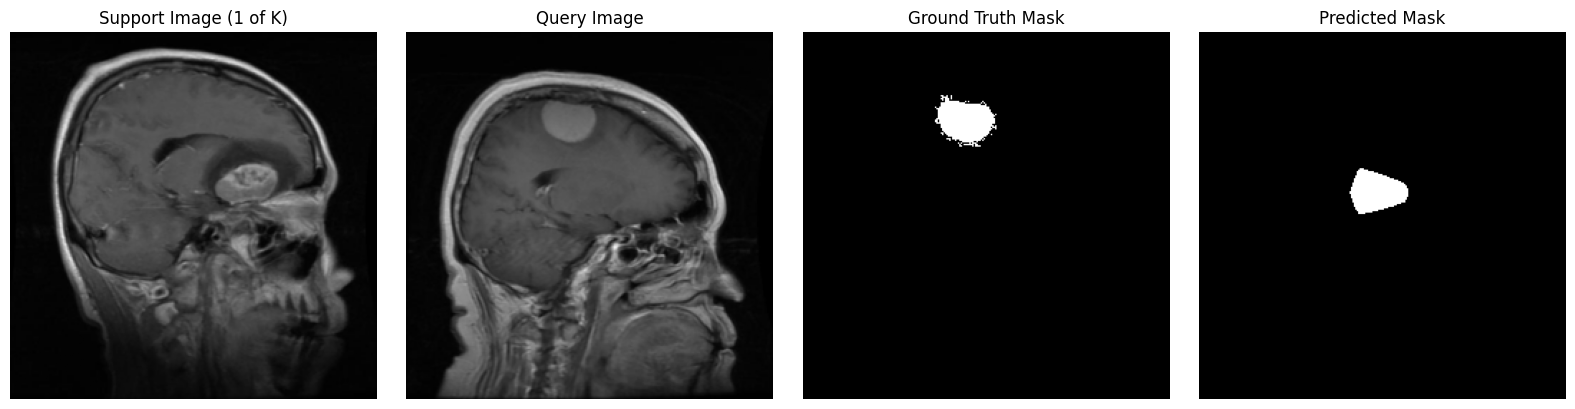

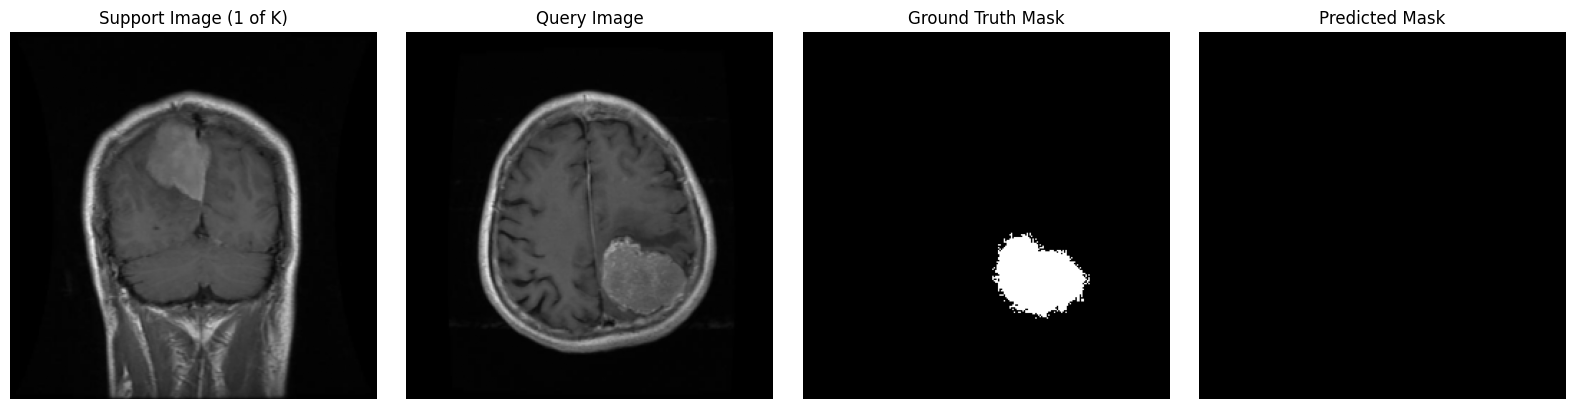

Fold 2 Results -> mIoU: 0.1080, Dice: 0.1711


FOLD 3 | Training on: ['glioma', 'meningioma'] | Evaluating on: ['pituitary']
Using 2 GPUs!
--- Starting Phase 1 (Frozen Backbone) (70 episodes) ---
  Phase 1 (Frozen Backbone) - Episode [10/70] Loss: 0.8059
  Phase 1 (Frozen Backbone) - Episode [20/70] Loss: 0.7902
  Phase 1 (Frozen Backbone) - Episode [30/70] Loss: 0.7558
  Phase 1 (Frozen Backbone) - Episode [40/70] Loss: 0.7848
  Phase 1 (Frozen Backbone) - Episode [50/70] Loss: 0.7603
  Phase 1 (Frozen Backbone) - Episode [60/70] Loss: 0.8295
  Phase 1 (Frozen Backbone) - Episode [70/70] Loss: 0.7744
ResNet50 backbone unfrozen.
--- Starting Phase 2 (Unfrozen Backbone) (300 episodes) ---
  Phase 2 (Unfrozen Backbone) - Episode [10/300] Loss: 0.7556
  Phase 2 (Unfrozen Backbone) - Episode [20/300] Loss: 0.7774
  Phase 2 (Unfrozen Backbone) - Episode [30/300] Loss: 0.7452
  Phase 2 (Unfrozen Backbone) - Episode [40/300] Loss: 0.8195
  Phase 2 (Unfrozen Backbone) - Episode [50/300] Loss: 

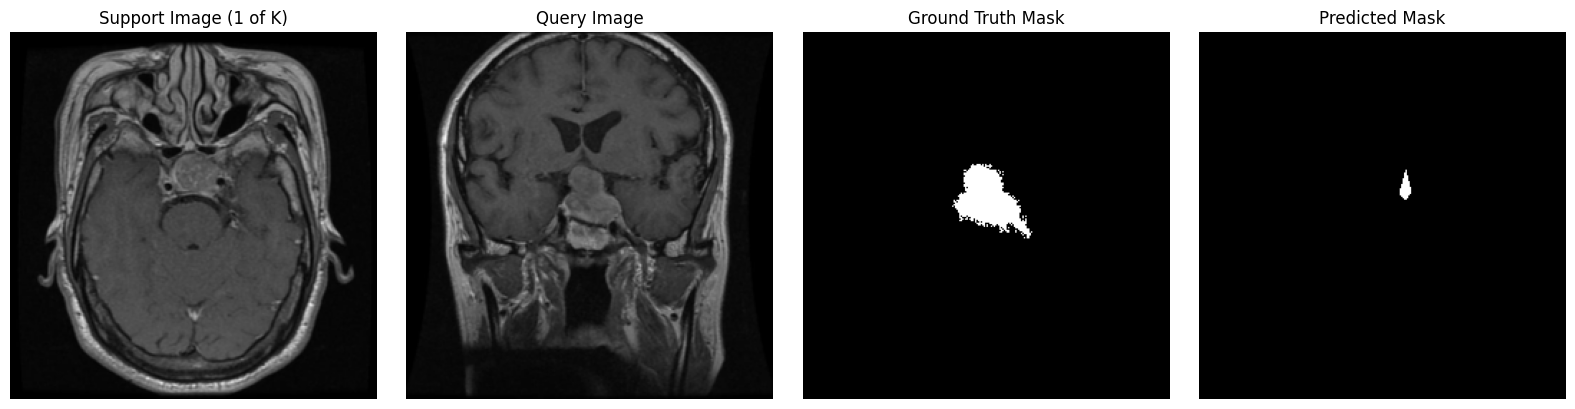

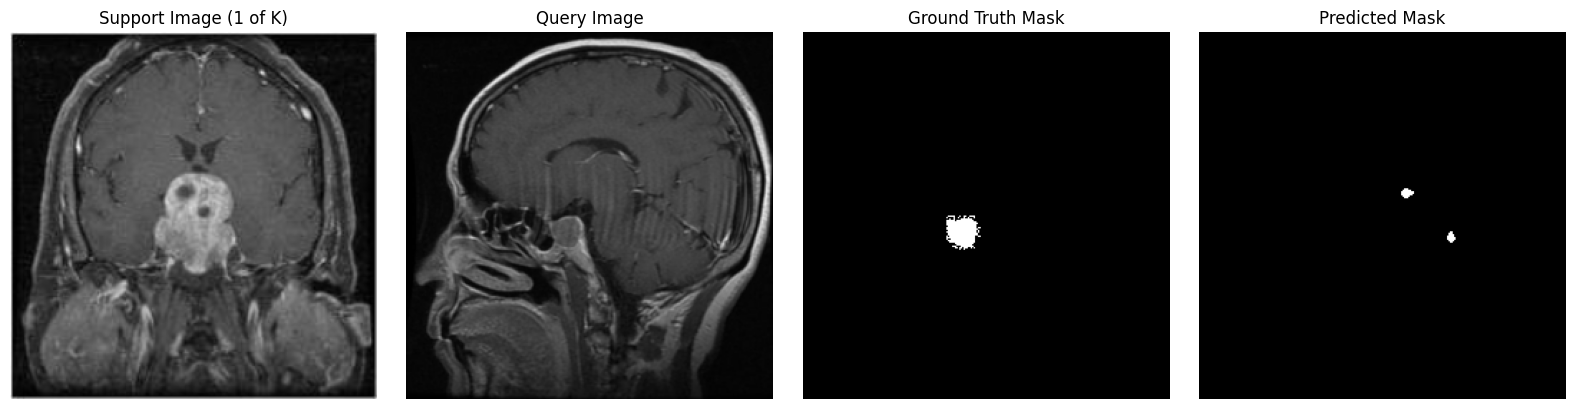

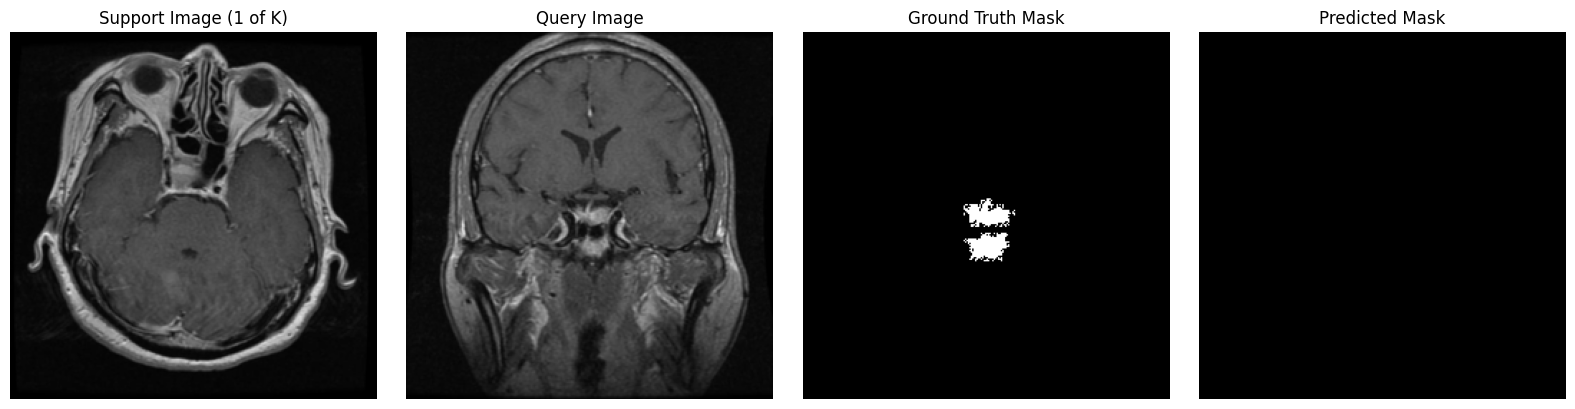

Fold 3 Results -> mIoU: 0.0014, Dice: 0.0027



In [17]:
dataset = TumorDataset(manifest_path=MANIFEST_PATH, data_root=DATA_ROOT)
available_classes = list(dataset.label_to_indices.keys())
print(f"Available classes: {available_classes}")

folds = []
for i, test_class in enumerate(available_classes):
    seen_classes = [c for c in available_classes if c != test_class]
    folds.append({'fold': i+1, 'seen': seen_classes, 'unseen': [test_class]})

for fold_info in folds:
    fold = fold_info['fold']
    seen = fold_info['seen']
    unseen = fold_info['unseen']
    
    print(f"\n=========================================")
    print(f"FOLD {fold} | Training on: {seen} | Evaluating on: {unseen}")
    print(f"=========================================")
    
    # Initialize Model (Backbone is frozen by default)
    model = DualBranchPANet().to(device)

    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs!")
        model = nn.DataParallel(model)
    
    # Setup Phase 1 Sampler (50 episodes)
    train_sampler_p1 = EpisodicBatchSampler(dataset.label_to_indices, seen, num_episodes=TRAIN_EPISODES_PHASE_1, k_shots=K_SHOTS, q_queries=Q_QUERIES)
    train_loader_p1 = DataLoader(dataset, batch_sampler=train_sampler_p1)
    
    # Phase 1 Optimizer (LR = 1e-4)
    optimizer_p1 = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_FROZEN)
    
    # Run Phase 1
    run_training_phase(model, train_loader_p1, optimizer_p1, TRAIN_EPISODES_PHASE_1, "Phase 1 (Frozen Backbone)")
    
    # Setup Phase 2
    if isinstance(model, nn.DataParallel):
        model.module.unfreeze_backbone()
    else:
        model.unfreeze_backbone()
    train_sampler_p2 = EpisodicBatchSampler(dataset.label_to_indices, seen, num_episodes=TRAIN_EPISODES_PHASE_2, k_shots=K_SHOTS, q_queries=Q_QUERIES)
    train_loader_p2 = DataLoader(dataset, batch_sampler=train_sampler_p2)
    
    # Phase 2 Optimizer (LR = 1e-5, updating all parameters now)
    optimizer_p2 = optim.AdamW(model.parameters(), lr=LR_UNFROZEN)
    
    # Run Phase 2
    run_training_phase(model, train_loader_p2, optimizer_p2, TRAIN_EPISODES_PHASE_2, "Phase 2 (Unfrozen Backbone)")
    
    # Save Fold Model
    os.makedirs("models", exist_ok=True)
    model_path = f"models/panet_fold_{fold}.pth"
    if isinstance(model, nn.DataParallel):
        torch.save(model.module.state_dict(), model_path)
    else:
        torch.save(model.state_dict(), model_path)
    print(f"Saved model to {model_path}\n")
    
    # Evaluation
    print(f"--- Evaluating Fold {fold} ---")
    model.eval()
    eval_sampler = EpisodicBatchSampler(dataset.label_to_indices, unseen, num_episodes=EVAL_EPISODES, k_shots=K_SHOTS, q_queries=Q_QUERIES)
    eval_loader = DataLoader(dataset, batch_sampler=eval_sampler)
    
    iou_list, dice_list = [], []
    
    with torch.no_grad():
        for ep_idx, (imgs, masks, labels) in enumerate(eval_loader):
            imgs, masks = imgs.to(device), masks.to(device)
            support_img = imgs[:K_SHOTS].unsqueeze(0)
            support_mask = masks[:K_SHOTS].unsqueeze(0)
            query_img = imgs[K_SHOTS:].unsqueeze(0).squeeze(1)
            target_mask = masks[K_SHOTS:].squeeze(1)
            
            logits, _ = model(support_img, query_img, support_mask)
            preds = logits.argmax(dim=1)
            
            pred_fg = (preds == 1).float()
            target_fg = target_mask.float()
            
            intersection = (pred_fg * target_fg).sum().item()
            union = pred_fg.sum().item() + target_fg.sum().item() - intersection
            
            iou = intersection / (union + 1e-5)
            dice = (2.0 * intersection) / (pred_fg.sum().item() + target_fg.sum().item() + 1e-5)
            
            iou_list.append(iou)
            dice_list.append(dice)
            
            if ep_idx < 3:
                save_visualization(support_img.squeeze(0), query_img, target_mask, preds, fold, ep_idx+1)
                
    mean_iou = sum(iou_list) / len(iou_list)
    mean_dice = sum(dice_list) / len(dice_list)
    print(f"Fold {fold} Results -> mIoU: {mean_iou:.4f}, Dice: {mean_dice:.4f}\n")
